In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data into a DataFrame
data = pd.read_csv('/home/mostah/workspace/fairness/scores/GD_results/decisionDirection.csv')

# # Bar chart for average scores
# plt.figure(figsize=(12, 6))
# sns.barplot(x='Folder Name', y='rouge1', data=data)
# plt.title('Average ROUGE-1 Scores by Group')
# plt.xticks(rotation=90)
# plt.ylabel('ROUGE-1 Score')
# plt.xlabel('Group')
# plt.tight_layout()
# plt.show()

# Heatmap for all scores
plt.figure(figsize=(18, 8))
sns.heatmap(data.set_index('Folder Name').T, annot=True, cmap='coolwarm')
plt.title('Heatmap of Scores by Group')
plt.ylabel('Metrics')
plt.xlabel('Group')
plt.tight_layout()
plt.show()


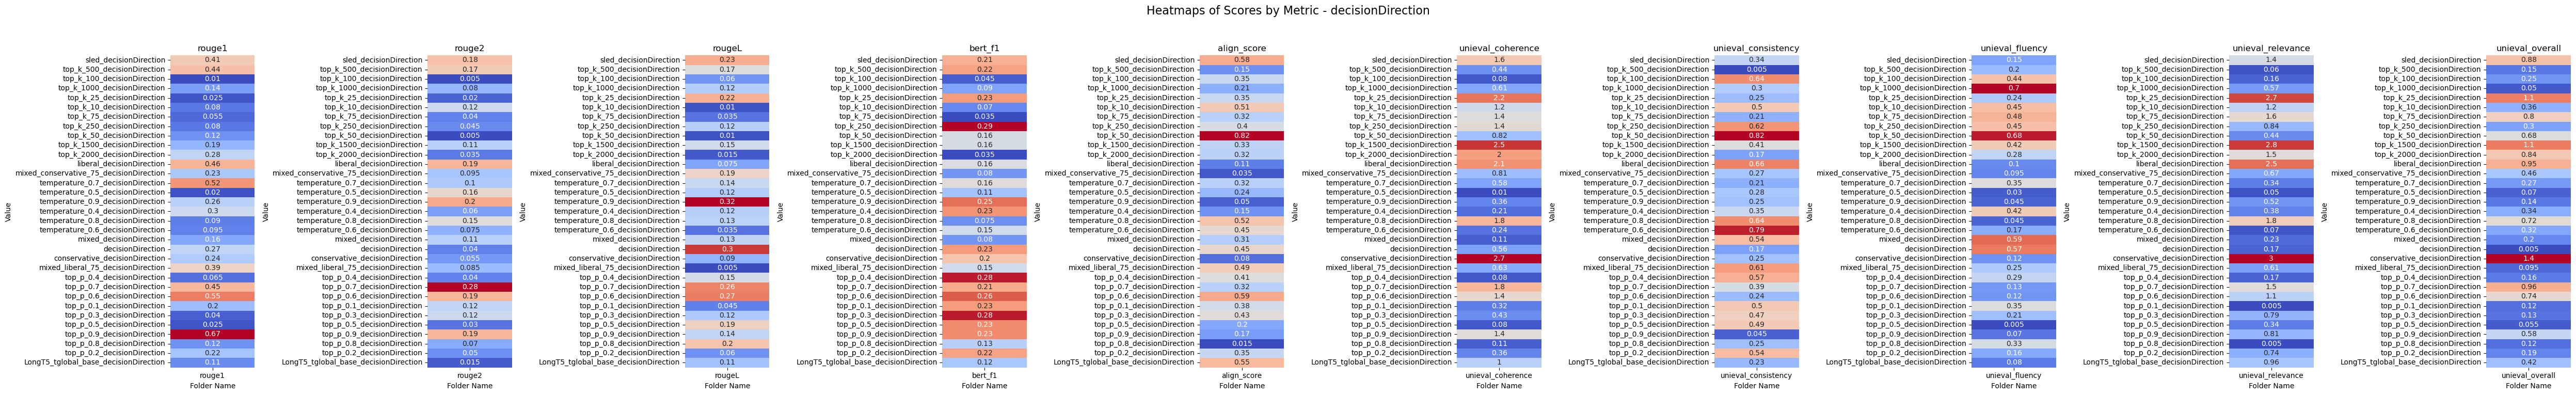

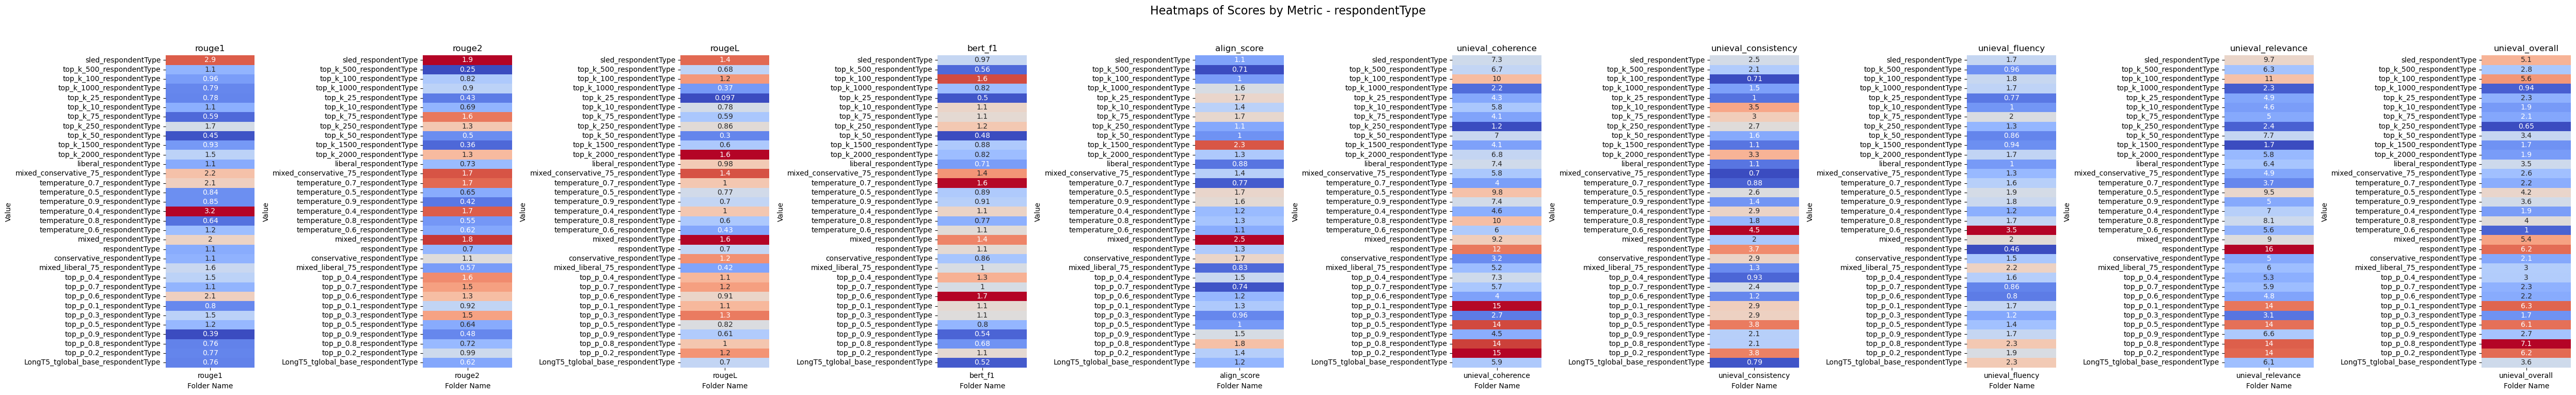

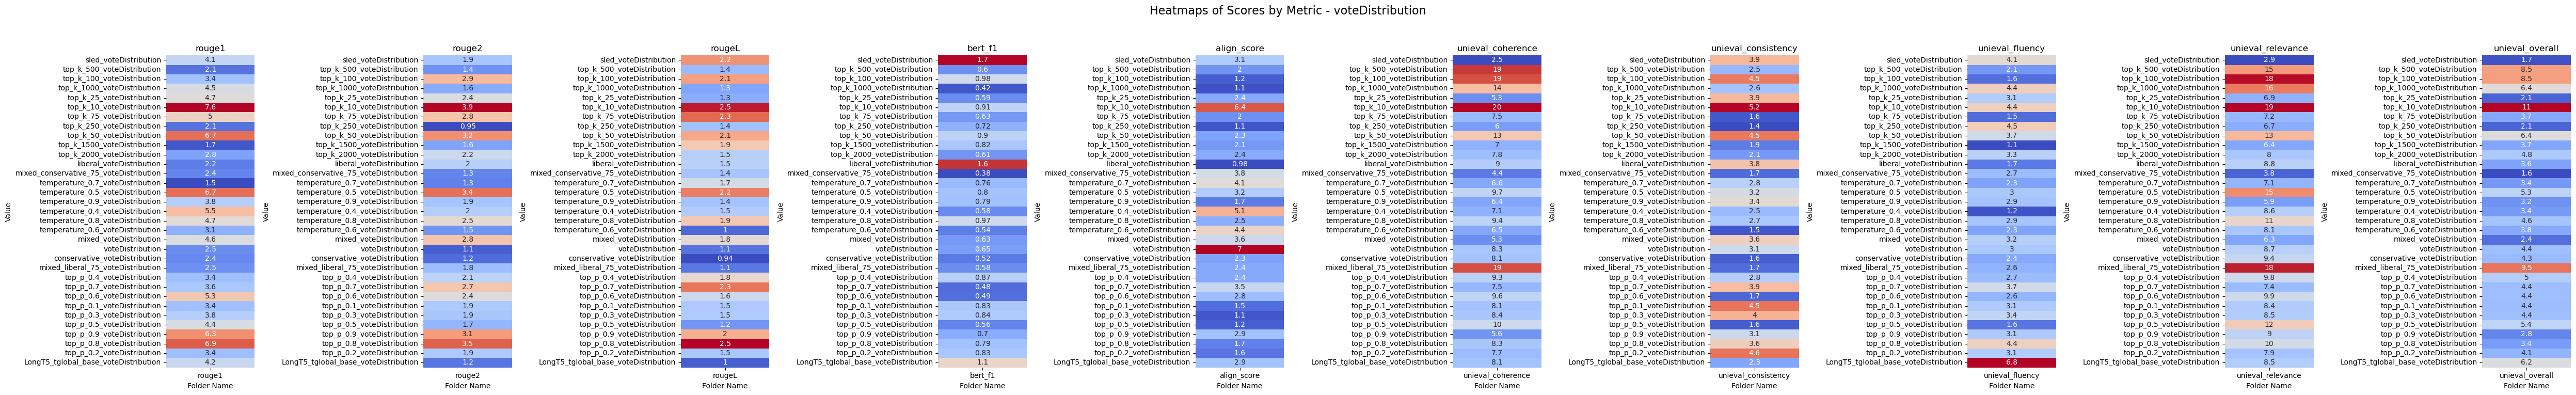

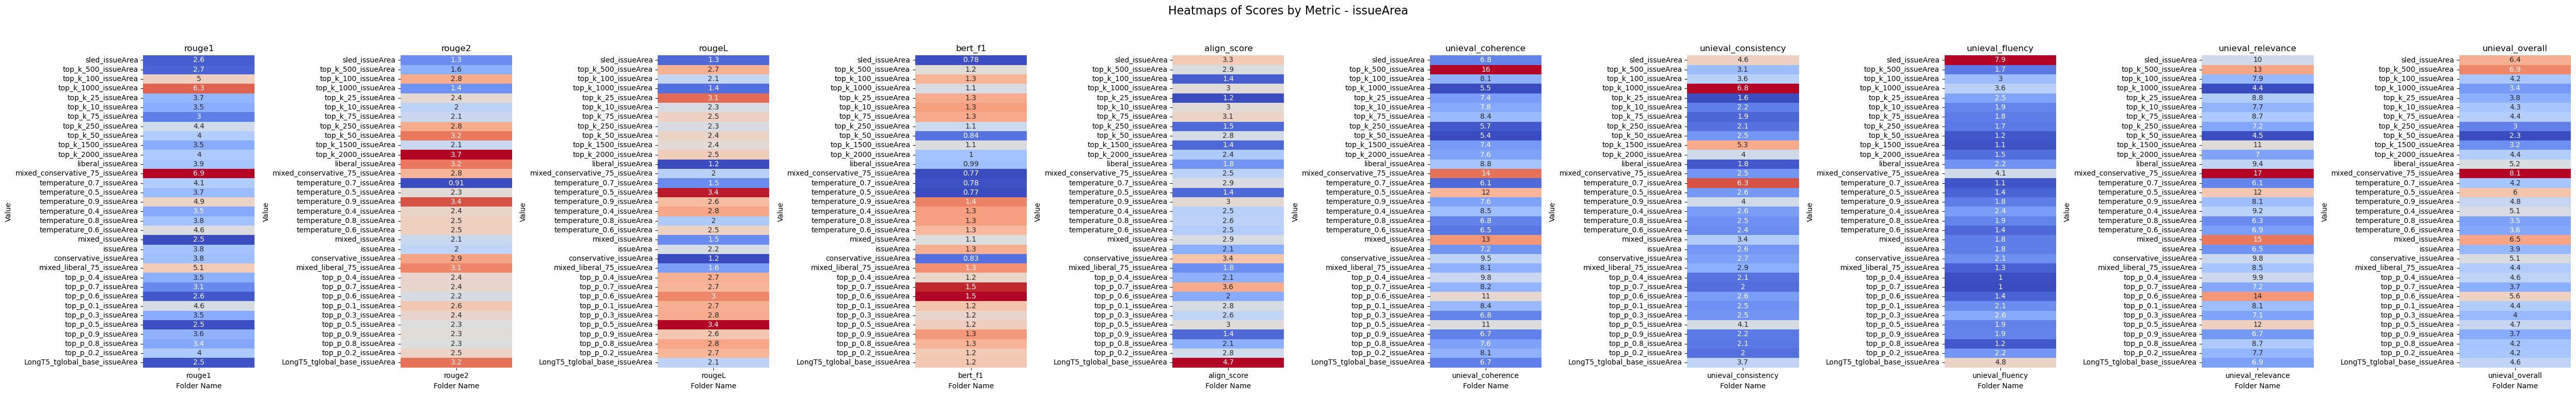

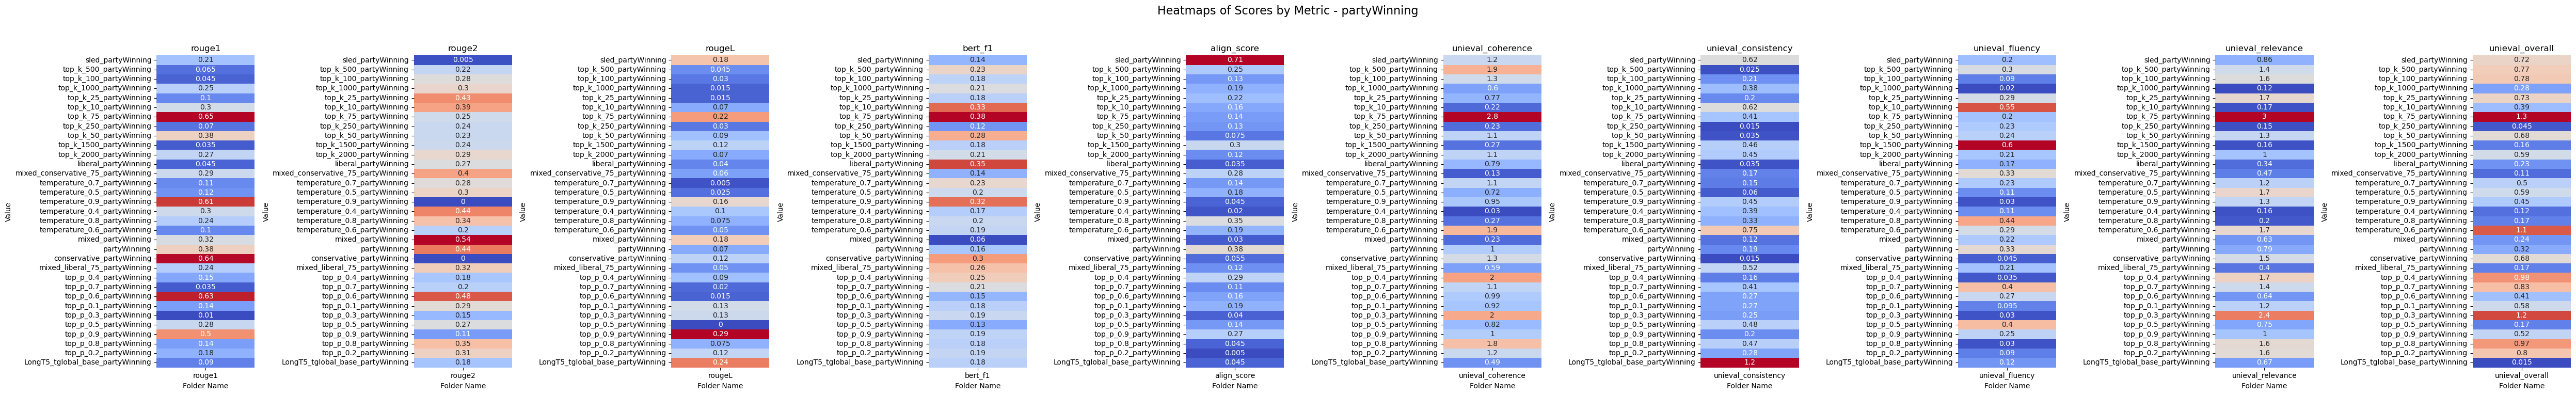

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Specify the path to the directory containing the CSV files
path = '/home/mostah/workspace/fairness/scores/GD_results/groups'

# Use glob to get all CSV files in the directory
csv_files = glob.glob(os.path.join(path, '*.csv'))

# Iterate over each CSV file
for csv_file in csv_files:
    # Load the data into a DataFrame
    data = pd.read_csv(csv_file)
    
    # Extract the file name without the directory and extension for the plot title
    file_name = os.path.basename(csv_file).replace('.csv', '')
    
    # Set 'Folder Name' as the index
    data.set_index('Folder Name', inplace=True)
    
    # Create a grid of subplots, one for each metric
    metrics = data.columns  # All columns except 'Folder Name' are metrics
    num_metrics = len(metrics)
    fig, axes = plt.subplots(nrows=1, ncols=num_metrics, figsize=(5 * num_metrics, 8))
    
    # Plot each metric in a separate subplot
    for ax, metric in zip(axes, metrics):
        # Plot the heatmap for each metric
        sns.heatmap(data[[metric]], annot=True, cmap='coolwarm', ax=ax, cbar=False)
        ax.set_title(metric)
        ax.set_xlabel('Folder Name')
        ax.set_ylabel('Value')
    
    # Set the main title for the entire figure
    plt.suptitle(f'Heatmaps of Scores by Metric - {file_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the main title
    
    # Show the plot
    plt.show()
